# Project name - FMCG Sales Drivers Analysis

## Causal and Statistical Analysis of Sales Drivers in FMCG Retail: A Multivariate Study.

# 1. Problem Definition (Scientific Method)

## Research Question
    This project aims to answer the following core question:
    What affects sales?
    Which operational, environmental, and store-level factors significantly drive FMCG beverage sales?

    More specifically, we investigate which operational, environmental, and store-level factors significantly influence sales performance.
    
## Business & Analytical Motivation
    Understanding sales drivers is critical for FMCG companies because it enables:

    - Improved demand forecasting
    - Optimized field operations (store visits)
    - Better allocation of refrigeration and branding equipment
    - Data-driven retail strategy decisions
    - Increased revenue efficiency across stores and regions

    This project bridges business intelligence and statistical modeling to identify both correlation and causal relationships.

## Hypotheses
    We test the following hypotheses using statistical and machine learning methods:
    H1: Store Visits Effect
        - Store visits have a positive and statistically significant impact on sales.
    H2: Weather Impact
         - Weather conditions (temperature, precipitation, humidity) significantly influence beverage demand.
    H3: Store Execution Effect
        - Stores with better execution (equipment, branding, availability) generate higher sales.
    H4: Heterogeneity Across Stores
        - The effect of operational and environmental drivers varies across: 
        regions
        store segments
        trade channels

# 2. DATA ARCHITECTURE
    The project integrates multiple data sources into a unified analytical dataset.
    
## CORE DATA (Business Layer)
### 1. SALES (target dataset)
    Contains daily transactional performance per store:
    date
    customer (store ID)
    revenue_bgn (sales value in BGN)
    cases (volume sold)

    This is the main dependent variable used in all models.
## OPERATIONS LAYER
### 2. VISITS 
    Represents field activity:
    Customer
    date
    visits (number of executed store visits)

    Measures sales force intensity and retail engagement.
### 3. COOLER / EQUIPMENT
    Represents in-store execution quality:
    customer
    equipment count
    branding
    status

    Captures availability and visibility of products in-store.
## MASTER STORE DATA
### 4. LIST DATASET
    Provides static store characteristics:
    customer
    region
    city
    channel
    segment

    Explains structural differences between stores.
## EXTERNAL ENVIRONMENT
### 5. WEATHER
    Daily environmental conditions per region:
    date
    temperature (°C)
    precipitation (mm)
    humidity (%)
    wind (km/h)
    holiday
    weekend
    non working day

    Captures external demand-driving conditions.

# 3. DATA INGESTION & INITIAL VALIDATION

Data Loading Strategy (Multi-source ingestion)

The dataset is constructed using multiple heterogeneous data sources including sales, store information, operational visits, equipment data, and external weather data.

Each dataset is loaded independently from cloud storage (Google Drive) to ensure modularity and reproducibility of the pipeline.

This approach allows separation of raw data ingestion from transformation logic, which improves maintainability and debugging.

### Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import holidays
import time

### DATA LOADING - RAW LAYER

In [2]:
# LOAD FROM GOOGLE DRIVE IDS

def load_drive(file_id, compression=None):
    url = f"https://drive.google.com/uc?export=download&id={file_id}"
    return pd.read_csv(url, compression=compression)


sales = load_drive("1g-2KlxWBgJwlVULMSh1jmXvPrzgpI0tJ", compression="gzip")
store = load_drive("1JlVGwR1koth70guNf8fygJx207qhn9eZ")
visits = load_drive("1gC53aiUNdGl5Za2Y0kr-iDW6-UPQWs1d")
cooler = load_drive("18M8gADRTypnnqWZkjQnkhVcl3Y6H1AGg")

### INITIAL DATA INSPECTION

In [3]:
datasets = {
    "sales": sales,
    "visits": visits,
    "cooler": cooler,
    "store": store
}

for name, df in datasets.items():
    print("\n", "="*40)
    print(name.upper())
    print(df.head())
    print(df.info())
    print("Shape:", df.shape)


SALES
         date  customer revenue_bgn cases
0  2025-01-01    103335        13,9     5
1  2025-01-01    106635       61,14    22
2  2025-01-01    103263        13,9     5
3  2025-01-01    106943       11,12     4
4  2025-01-01    111148       61,14    22
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 662041 entries, 0 to 662040
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   date         662041 non-null  object
 1   customer     662041 non-null  int64 
 2   revenue_bgn  662041 non-null  object
 3   cases        662041 non-null  object
dtypes: int64(1), object(3)
memory usage: 20.2+ MB
None
Shape: (662041, 4)

VISITS
   Customer       date  Executed\nVisits All
0    111009  16.6.2025                     1
1    111009  24.6.2025                     2
2    111009  23.7.2025                     2
3    111009  12.8.2025                     1
4    111009  18.8.2025                     1
<class 'pandas.core.frame.

# 4. DATA CLEANING & STANDARDIZATION

After loading, all datasets undergo a standardized preprocessing pipeline to ensure structural consistency across sources.

This includes:

    - Standardization of column names (removal of hidden characters and formatting inconsistencies)
    - Harmonization of naming conventions across datasets (e.g., Customer → customer)
    - Conversion of numerical fields stored as strings into numeric format (e.g., revenue, cases)
    - Transformation of date fields into datetime format for downstream processing

This step ensures all datasets share a consistent schema prior to integration.

Time Alignment

All datasets are aligned at daily granularity using a unified date key (date).

All timestamps are converted to datetime format using consistent parsing rules,
ensuring temporal consistency across all sources.

### COLUMN CLEANING

In [4]:
# remove hidden characters BEFORE everything else
def clean_cols(df):
    df.columns = (
        df.columns
        .str.replace("\n", " ")
        .str.replace("\r", " ")
        .str.strip()
    )
    return df

sales = clean_cols(sales)
visits = clean_cols(visits)
cooler = clean_cols(cooler)
store = clean_cols(store)

### RENAME COLUMNS - STANDARDIZATION LAYER

In [5]:
visits = visits.rename(columns={
    "Calendar day": "date",
    "Customer": "customer",
    "Executed Visits All": "visits"
})

store = store.rename(columns={
    "Customer": "customer"
})

cooler = cooler.rename(columns={
    "Customer": "customer",
    "Number of Equipments": "equipment_count"
})

### TYPE CONVERSION 

In [6]:
# SALES
sales["date"] = pd.to_datetime(sales["date"], errors="coerce")
sales["revenue_bgn"] = (
    sales["revenue_bgn"].astype(str).str.replace(",", ".")
)
sales["revenue_bgn"] = pd.to_numeric(sales["revenue_bgn"], errors="coerce")
sales["cases"] = pd.to_numeric(sales["cases"], errors="coerce")

# VISITS
visits["date"] = pd.to_datetime(visits["date"], errors="coerce", dayfirst=True)
visits["visits"] = pd.to_numeric(visits["visits"], errors="coerce")

### DATA QUALITY CHECK 

In [7]:
print("SALES:", sales.columns.tolist())
print("VISITS:", visits.columns.tolist())
print("STORE:", store.columns.tolist())
print("COOLER:", cooler.columns.tolist())

SALES: ['date', 'customer', 'revenue_bgn', 'cases']
VISITS: ['customer', 'date', 'visits']
STORE: ['customer', 'Customer Name', 'Region', 'City', 'Trade Channel', 'Segment', 'Seasonal', 'Тype']
COOLER: ['customer', 'Type', 'Branding', 'Status', 'Number of  Equipments', 'Number of doors']


### WEATHER PIPELINE (EXTERNAL DATA SOURCE)

In [8]:
def get_weather(city, lat, lon):
    url = "https://archive-api.open-meteo.com/v1/archive"

    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": "2025-01-01",
        "end_date": "2025-12-31",
        "daily": [
            "temperature_2m_mean",
            "precipitation_sum",
            "relative_humidity_2m_mean",
            "windspeed_10m_max"
        ],
        "timezone": "Europe/Sofia"
    }

    r = requests.get(url, params=params)
    data = r.json()["daily"]

    df = pd.DataFrame(data)
    df["city"] = city
    return df


cities = {
     "Varna": (43.2141, 27.9147),
    "Burgas": (42.5048, 27.4626),
    "Shumen": (43.2712, 26.9361),
    "Ruse": (43.8356, 25.9657),
    "Sliven": (42.6818, 26.3227),
    "Veliko Tarnovo": (43.0757, 25.6172),
    "Yambol": (42.4840, 26.5030),
    "Targovishte": (43.2512, 26.5729),
    "Razgrad": (43.5333, 26.5167),
    "Dobrich": (43.5667, 27.8333),
    "Silistra": (44.1167, 27.2667),
    "Stara Zagora": (42.4258, 25.6345),
    "Plovdiv": (42.1354, 24.7453),
    "Pleven": (43.4170, 24.6067),
    "Gabrovo": (42.8747, 25.3342)
}

all_weather = []

for city, (lat, lon) in cities.items():
    print("Downloading:", city)
    df = get_weather(city, lat, lon)
    all_weather.append(df)
    time.sleep(1)
    
print("Download completed.")

weather = pd.concat(all_weather, ignore_index=True)

weather = weather.rename(columns={
    "time": "date",
    "temperature_2m_mean": "temperature_celsius",
    "precipitation_sum": "precipitation_mm",
    "relative_humidity_2m_mean": "humidity_percent",
    "windspeed_10m_max": "wind_speed_kmh"
})

weather["date"] = pd.to_datetime(weather["date"])

Downloading: Varna
Downloading: Burgas
Downloading: Shumen
Downloading: Ruse
Downloading: Sliven
Downloading: Veliko Tarnovo
Downloading: Yambol
Downloading: Targovishte
Downloading: Razgrad
Downloading: Dobrich
Downloading: Silistra
Downloading: Stara Zagora
Downloading: Plovdiv
Downloading: Pleven
Downloading: Gabrovo
Download completed.


# 5. DATA INTEGRATION & CROSS-SOURCE MAPPING

### Region–Weather Mapping Logic

Weather data is not directly available per store, but only per city.

However, store-level data contains regional identifiers in Bulgarian language, while weather dataset uses English city names.

To resolve this mismatch, a mapping layer is introduced:

    Bulgarian Region → English City Name mapping

Example:

    “Варна” → “Varna”
    “Бургас” → “Burgas”

This mapping ensures correct alignment between:

    Store location (business layer)
    Weather conditions (external environment layer)

In [9]:
# REGION → CITY MAPPING 

region_to_city = {
    "Варна": "Varna",
    "Бургас": "Burgas",
    "Шумен": "Shumen",
    "Русе": "Ruse",
    "Сливен": "Sliven",
    "Велико Търново": "Veliko Tarnovo",
    "Ямбол": "Yambol",
    "Търговище": "Targovishte",
    "Разград": "Razgrad",
    "Добрич": "Dobrich",
    "Силистра": "Silistra",
    "Стара Загора": "Stara Zagora",
    "Пловдив": "Plovdiv",
    "Плевен": "Pleven",
    "Габрово": "Gabrovo"
}

In [10]:
store["Region_en"] = store["Region"].map(region_to_city)

print(store.head())

   customer    Customer Name  Region           City Trade Channel Segment  \
0    111009  ЛАФКА ЧОЧО ЕООД   Варна  ЗЛАТНИ ПЯСЪЦИ        Hotels    Gold   
1    110234     ПАВИЛЬО ЕООД   Варна          ВАРНА     Fast-food  Silver   
2    110445   КРАСМОС 2 ЕООД  Бургас         БУРГАС     Fast-food    Iron   
3    110455     МАГАЗИН ЕООД  Бургас   СЛЪНЧЕВ БРЯГ     Fast-food    Gold   
4    110453    ГЕОРГИЕВ ЕООД  Бургас   СЛЪНЧЕВ БРЯГ     Fast-food    Gold   

       Seasonal         Тype Region_en  
0      Seasonal  Out of Home     Varna  
1  Not Seasonal  Out of Home     Varna  
2  Not Seasonal  Out of Home    Burgas  
3      Seasonal  Out of Home    Burgas  
4      Seasonal  Out of Home    Burgas  


### DATA INTEGRATION & MASTER DATASET CONSTRUCTION

After standardization and mapping, all datasets are merged into a single analytical table using the following keys:

    Primary key: customer
    Temporal key: date
    Environmental join key: Region → City mapping

The final integration follows this order:

   1. Sales + Visits (customer + date)
   2. Store attributes (customer)
3. Equipment data (customer)
4. Weather data (date + mapped city)

This results in a unified panel dataset containing:

    Sales performance
    Operational intensity
    Store characteristics
    Environmental conditions

In [11]:
df = sales.merge(visits, on=["customer", "date"], how="left")

df = df.merge(store, on="customer", how="left")

df = df.merge(cooler, on="customer", how="left")

# WEATHER MERGE (correct alignment: date + city)
df = df.merge(
    weather,
    left_on=["date", "Region_en"],
    right_on=["date", "city"],
    how="left"
)

df = df.drop(columns=["Region_en", "city"])

### FEATURE ENGINEERING

In [12]:
df["sales_per_case"] = df["revenue_bgn"] / (df["cases"] + 1)
df["sales_per_visit"] = df["revenue_bgn"] / (df["visits"] + 1)

df["high_visit"] = df["visits"] > df["visits"].median()

df["temperature_bucket"] = pd.cut(
    df["temperature_celsius"],
    bins=[-10, 10, 25, 40],
    labels=["cold", "mild", "hot"]
)

df["is_active_store"] = df["Status"].notna()

### FINAL CHECK

Outcome of Pipeline

The final dataset enables:

    Time-series consistency across all variables
    Cross-sectional comparability across stores
    Correct alignment of weather effects by region
    Reliable basis for regression and causal analysis

In [13]:
print(df.shape)
print(df.head())
print(df.isna().sum().head(10))

# --- if we want to save the date in .csv ---

# output_path = "weather_dataset_bg.csv"
# df.to_csv(output_path, index=False)

(1080964, 26)
        date  customer  revenue_bgn  cases  visits              Customer Name  \
0 2025-01-01    103335        13.90    5.0     NaN               МАГАЗИН ЕООД   
1 2025-01-01    103335        13.90    5.0     NaN               МАГАЗИН ЕООД   
2 2025-01-01    103335        13.90    5.0     NaN               МАГАЗИН ЕООД   
3 2025-01-01    106635        61.14   22.0     NaN  БЪРЗО ХРАНЕНЕ КАЗИНО ЕООД   
4 2025-01-01    103263        13.90    5.0     NaN          БИСТРО МУЗЕЯ ЕООД   

   Region      City Trade Channel Segment  ... Number of doors  \
0  Добрич  ЛЮЛЯКОВО    Local Shop  Bronze  ...               1   
1  Добрич  ЛЮЛЯКОВО    Local Shop  Bronze  ...               1   
2  Добрич  ЛЮЛЯКОВО    Local Shop  Bronze  ...             0,7   
3  Добрич    БАЛЧИК     Superette    Gold  ...               3   
4  Добрич  ОБРОЧИЩЕ    Local Shop    Gold  ...               0   

  temperature_celsius precipitation_mm humidity_percent wind_speed_kmh  \
0                 5.1       

# 4. EXPLORATORY DATA ANALYSIS (EDA)

    The goal of the exploratory analysis is to identify patterns, distributions, and relationships between sales and potential explanatory variables.

    We perform:

    4.1 Univariate Analysis

We analyze the distribution of key variables such as:

revenue (sales)
store visits
equipment availability

This helps identify skewness, outliers, and general data behavior.

4.2 Bivariate Analysis

We examine relationships between:

Store visits and sales
Temperature and sales
Equipment availability and sales

These relationships provide early evidence of potential causal effects.

4.3 Multivariate Analysis

We extend the analysis to multiple variables simultaneously by:

correlation matrix analysis
segmentation by store type and region
grouping stores based on performance levels

This allows identification of interaction effects and hidden patterns in the data.

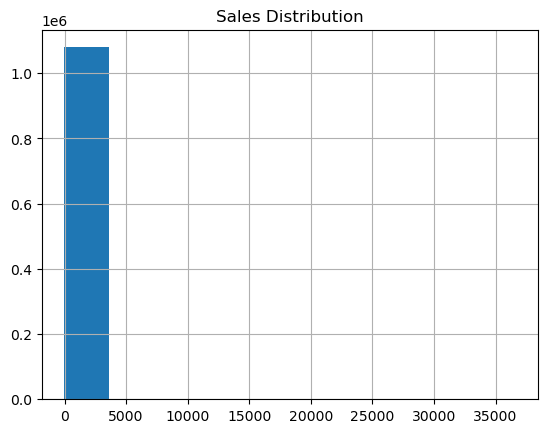

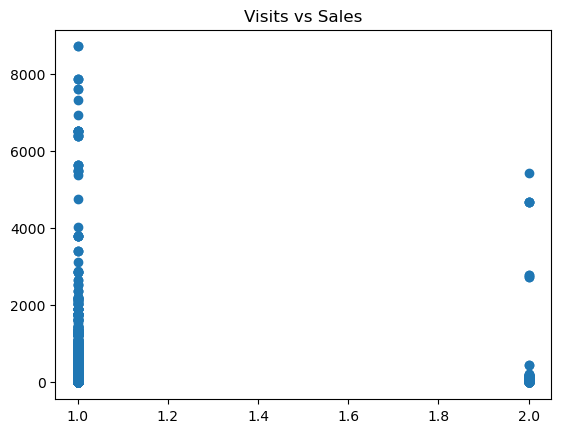

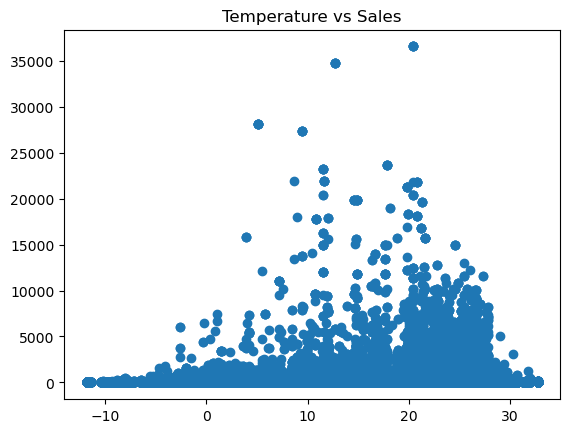

In [14]:


# SALES DISTRIBUTION
df["revenue_bgn"].hist()
plt.title("Sales Distribution")
plt.show()

# VISITS vs SALES
plt.scatter(df["visits"], df["revenue_bgn"])
plt.title("Visits vs Sales")
plt.show()

# TEMPERATURE vs SALES
plt.scatter(df["temperature_celsius"], df["revenue_bgn"])
plt.title("Temperature vs Sales")
plt.show()

In [15]:
df["Status"]

0          placed
1          placed
2          placed
3          placed
4          placed
            ...  
1080959       NaN
1080960    placed
1080961    placed
1080962       NaN
1080963       NaN
Name: Status, Length: 1080964, dtype: object

# 5. STATISTICAL INFERENCE

To move beyond descriptive analysis, we apply statistical hypothesis testing to validate relationships observed in the data.

5.1 Correlation Analysis

We measure linear relationships between variables using Pearson correlation:

visits vs sales
temperature vs sales
equipment vs sales

This helps quantify the strength and direction of relationships.

5.2 T-Test Analysis

We compare means between two groups:

High visit stores vs low visit stores

Objective:

Determine whether store visits significantly affect sales performance.

5.3 ANOVA Analysis

We extend the comparison across multiple groups:

Store segments (Bronze, Silver, Gold)
Regional performance groups

Objective:

Test whether differences in sales are statistically significant across categories.

5.4 Hypothesis Evaluation

Each hypothesis is evaluated based on p-values and statistical significance thresholds (α = 0.05).

# 6. REGRESSION MODELING

To quantify the combined effect of multiple variables on sales, we construct a multivariate linear regression model.

The model is defined as:

Sales = f(visits, temperature, humidity, equipment, store characteristics)

Model Objective:
Estimate the magnitude of each driver
Identify statistically significant predictors
Measure overall explanatory power (R²)
Interpretation:
Positive coefficients indicate drivers that increase sales
Negative coefficients indicate inhibitory effects
Statistical significance determines reliability of predictors

# 7. ADVANCED INSIGHTS

To deepen the analysis, we explore:

7.1 Interaction Effects

We analyze whether combined effects exist between variables:

Visits * Weather conditions
Store execution * Store type

7.2 Lag Effects

We test whether past operational activity influences future sales:

Previous visits -> current sales
7.3 Seasonality Effects

We evaluate temporal patterns:

Weekend vs weekday behavior
Holiday vs non-holiday effects

# 8. CONCLUSION

The analysis identifies key drivers of FMCG beverage sales across operational, environmental, and structural dimensions.

Key findings include:

Store visits significantly influence sales performance
Weather conditions play an important role in demand variation
Store execution quality contributes to sales differences across locations
The combined model explains a substantial portion of sales variability

These findings provide actionable insights for optimizing field operations and improving retail performance.